In [6]:
import pandas as pd
import numpy as np
import os

os.makedirs('../img', exist_ok=True)

ABLATION_SYSTEMS = {
    'blendsql_np64_cffalse_cdfalse_eefalse': ('Baseline', 0),
    'blendsql_np64_cffalse_cdtrue_eefalse': ('+CD', 1),
    'blendsql_np64_cftrue_cdtrue_eefalse': ('+CD+CF', 2),
}
FULL_SYSTEM = 'blendsql'

tasks = ['movie', 'ecomm', 'mmqa', 'wildlife', 'cars']
models = ['gemma_e2b', 'gemma_e4b']
model_labels = {'gemma_e2b': 'Gemma E2B', 'gemma_e4b': 'Gemma E4B'}

rows = []
for task in tasks:
    for model in models:
        path = f'../results/feature_ablations/{task}/{model}/all_results_with_runs.csv'
        df = pd.read_csv(path, usecols=['system_name', 'query_name', 'latency', 'quality'])
        per_query = df.groupby(['system_name', 'query_name'])[['latency', 'quality']].mean().reset_index()
        for system_name, (label, order) in ABLATION_SYSTEMS.items():
            subset = per_query[per_query.system_name == system_name]
            if len(subset) == 0:
                continue
            rows.append({
                'task': task, 'model': model_labels[model],
                'step': label, 'step_order': order,
                'latency': subset['latency'].mean(),
                'quality': subset['quality'].mean(),
            })

        path2 = f'../results/blendsql_comparison_to_closed/{task}/{model}/all_results_with_runs.csv'
        df2 = pd.read_csv(path2, usecols=['system_name', 'query_name', 'latency', 'quality'])
        per_query2 = (
            df2[df2.system_name == FULL_SYSTEM]
            .groupby('query_name')[['latency', 'quality']].mean()
            .reset_index()
        )
        rows.append({
            'task': task, 'model': model_labels[model],
            'step': 'Full (+EE)', 'step_order': 3,
            'latency': per_query2['latency'].mean(),
            'quality': per_query2['quality'].mean(),
        })

plot_df = pd.DataFrame(rows)
plot_df

,task,model,step,step_order,latency,quality
0,movie,Gemma E2B,Baseline,0,14.585237,0.609523
1,movie,Gemma E2B,+CD,1,17.431597,0.617645
2,movie,Gemma E2B,+CD+CF,2,17.390230,0.622419
3,movie,Gemma E2B,Full (+EE),3,6.308665,0.611619
4,movie,Gemma E4B,Baseline,0,21.861245,0.726878
5,movie,Gemma E4B,+CD,1,25.874679,0.736960
6,movie,Gemma E4B,+CD+CF,2,25.908531,0.724050
7,movie,Gemma E4B,Full (+EE),3,9.166067,0.729601
8,ecomm,Gemma E2B,Baseline,0,18.349870,0.410160
9,ecomm,Gemma E2B,+CD,1,18.686438,0.579280


Saved.


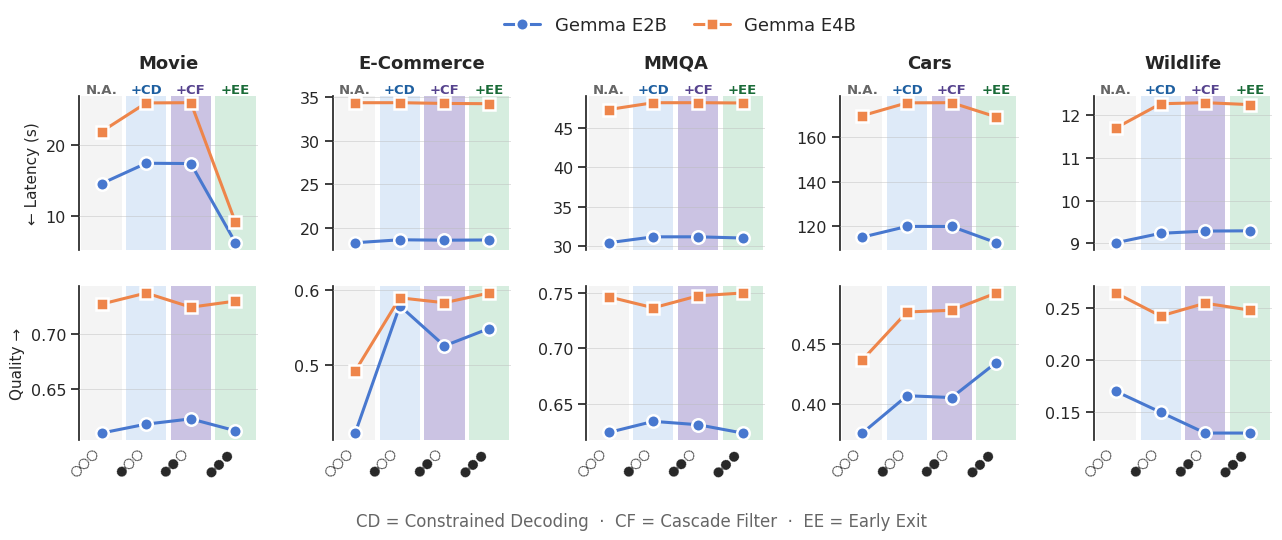

In [7]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from matplotlib.transforms import blended_transform_factory

sns.set_theme(style='ticks', font_scale=1.05)
plt.rcParams.update({'font.family': 'sans-serif'})

# --- Design constants ---
TASKS = ['movie', 'ecomm', 'mmqa', 'cars', 'wildlife']
TASK_LABELS = {'movie': 'Movie', 'ecomm': 'E-Commerce', 'mmqa': 'MMQA', 'cars': 'Cars', 'wildlife': 'Wildlife'}
METRICS = [('latency', '← Latency (s)'), ('quality', 'Quality →')]
MODELS = ['Gemma E2B', 'Gemma E4B']

MODEL_COLORS  = {'Gemma E2B': '#4878CF', 'Gemma E4B': '#EE854A'}
MODEL_MARKERS = {'Gemma E2B': 'o',       'Gemma E4B': 's'}

# Background fill per step — encodes cumulative feature build-up
STEP_BG = ['#f4f4f4', '#deeaf8', '#CBC3E3', '#d6eddf']

# Header label colors: darker shades of each zone's hue so they visually match
STEP_HEADER_COLORS = ['#666666', '#1e5fa0', '#56438E', '#1a6b38']

# X-tick labels: step name (line 1) + feature checklist (line 2)
# ○ = feature off, ● = feature on;  order: CD  CF  EE
# XTICK_LABELS = [
#     'Baseline\n○  ○  ○',
#     '+CD\n●  ○  ○',
#     '+CD+CF\n●  ●  ○',
#     'Full (+EE)\n●  ●  ●',
# ]

XTICK_LABELS = [
    '○○○',
    '●○○',
    '●●○',
    '●●●',
]

# --- Build figure ---
fig, axes = plt.subplots(
    len(METRICS), len(TASKS),
    figsize=(13, 5),
    sharey=False,
    sharex=True,
)

for row_i, (metric, metric_label) in enumerate(METRICS):
    for col_j, task in enumerate(TASKS):
        ax = axes[row_i, col_j]
        task_df = plot_df[plot_df['task'] == task].sort_values('step_order')

        # ── Background zones ───────────────────────────────────────────────
        for k, bg in enumerate(STEP_BG):
            ax.axvspan(k - 0.45, k + 0.45, color=bg, zorder=0, linewidth=0)

        for x_sep in [0.5, 1.5, 2.5]:
            ax.axvline(x=x_sep, color='white', linewidth=1.5, zorder=1)

        # ── Data lines ────────────────────────────────────────────────────
        for model in MODELS:
            mdf = task_df[task_df['model'] == model].sort_values('step_order')
            x = mdf['step_order'].values
            y = mdf[metric].values
            ax.plot(
                x, y,
                color=MODEL_COLORS[model],
                marker=MODEL_MARKERS[model],
                linewidth=2.2,
                markersize=9,
                markeredgewidth=1.8,
                markeredgecolor='white',
                label=model,
                zorder=4,
                solid_capstyle='round',
            )

        # ── Feature-step header (top row only) ────────────────────────────
        if row_i == 0:
            trans = blended_transform_factory(ax.transData, ax.transAxes)
            STEP_NAMES = ['N.A.', '+CD', '+CF', '+EE']
            for k, (sname, scol) in enumerate(zip(STEP_NAMES, STEP_HEADER_COLORS)):
                ax.text(
                    k, 1.0, sname,
                    transform=trans, ha='center', va='bottom',
                    fontsize=9.5, color=scol, fontweight='bold',
                    clip_on=False,
                )

        # ── Axes formatting ────────────────────────────────────────────────
        ax.set_xticks([0, 1, 2, 3])
        ax.set_xlim(-0.5, 3.5)

        if row_i == len(METRICS) - 1:
            ax.set_xticklabels(XTICK_LABELS, fontsize=9.5, ha='right', rotation=45, linespacing=1.5)
        else:
            ax.set_xticklabels([])

        ax.tick_params(axis='x', length=0, pad=4)
        ax.set_ylabel(metric_label if col_j == 0 else '', fontsize=11)

        if row_i == 0:
            ax.set_title(TASK_LABELS[task], fontsize=13, fontweight='bold', pad=20)

        sns.despine(ax=ax, bottom=True)
        ax.yaxis.grid(True, alpha=0.45, linewidth=0.7, color='#bbbbbb')
        ax.set_axisbelow(False)

# ── Legend — flat, above the figure ───────────────────────────────────────
legend_handles = [
    mlines.Line2D(
        [], [],
        color=MODEL_COLORS[m], marker=MODEL_MARKERS[m],
        markersize=9, markeredgewidth=1.8, markeredgecolor='white',
        linewidth=2.2, label=m,
    )
    for m in MODELS
]
fig.legend(
    handles=legend_handles,
    loc='upper center',
    ncol=len(MODELS),
    bbox_to_anchor=(0.53, 1.07),
    fontsize=13,
    frameon=False,
    handlelength=2,
    columnspacing=1.5,
)

fig.supxlabel(
    'CD = Constrained Decoding  ·  CF = Cascade Filter  ·  EE = Early Exit',
    fontsize=12, color='#666666', x=0.5
)
fig.tight_layout(rect=[0, 0, 1, 1], h_pad=1.8, w_pad=1.5)
fig.savefig('../img/feature_ablation_plot.pdf', bbox_inches='tight')
fig.savefig('../img/feature_ablation_plot.png', dpi=150, bbox_inches='tight')
print('Saved.')
plt.show()